### Multi-Modal Clustering

Combines **both** the 1037 labeled proteins (with real text metadata) and the ~961 unlabeled
proteins (with generated text from V3 model) into one unified clustering.


In [9]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
import hdbscan
import umap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = '../results/prot2func_gpcr_output_v3'
DATA_DIR   = '../data/processed'
FIG_DIR    = '../results/figures'
os.makedirs(FIG_DIR, exist_ok=True)


#### Load Labeled + Unlabeled Data

In [10]:
import scipy.sparse

# =======================================================
#  1a. LABELED proteins (1037) — real text metadata
# =======================================================
text_df = pd.read_csv(os.path.join(DATA_DIR, 'uniprot_all_fields_cache.csv'))
text_df = text_df.rename(columns={'Entry': 'ID'})
labeled_ids = text_df['ID'].tolist()

seq_df = pd.read_csv(os.path.join(DATA_DIR, 'embedding_sequences_mean_pooling.csv'))
if 'uniref_id' in seq_df.columns:
    seq_df = seq_df.rename(columns={'uniref_id': 'ID'})
elif 'Unnamed: 0' in seq_df.columns:
    seq_df = seq_df.rename(columns={'Unnamed: 0': 'ID'})
seq_df = seq_df.set_index('ID').reindex(labeled_ids).reset_index()
labeled_seq_emb = seq_df.iloc[:, 1:1281].values.astype(np.float32)

labeled_sbert = np.load(os.path.join(DATA_DIR, 'embeddings_sbert.npy'))
labeled_tfidf_sparse = scipy.sparse.load_npz(os.path.join(DATA_DIR, 'embeddings_tfidF.npz'))

print(f'LABELED ({len(labeled_ids)} proteins):')
print(f'  ESM2   : {labeled_seq_emb.shape}')
print(f'  SBERT  : {labeled_sbert.shape}')
print(f'  TF-IDF : {labeled_tfidf_sparse.shape}')

# =======================================================
#  1b. UNLABELED proteins (~961) — generated text from V3
# =======================================================
esm2_ul = pd.read_csv(os.path.join(DATA_DIR, 'data_esm2_mean_pooling_without_id.csv'))
id_col = 'uniref_id' if 'uniref_id' in esm2_ul.columns else esm2_ul.columns[0]
esm2_ul = esm2_ul.rename(columns={id_col: 'ID'})
unlabeled_ids = esm2_ul['ID'].tolist()
unlabeled_seq_emb = esm2_ul.drop(columns=['ID']).values.astype(np.float32)

pred_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'unlabeled_predictions.csv'))
pred_df = pred_df.set_index('ID').reindex(unlabeled_ids).reset_index()
generated_texts = pred_df['generated_text'].fillna('').tolist()

print(f'\nUNLABELED ({len(unlabeled_ids)} proteins):')
print(f'  ESM2           : {unlabeled_seq_emb.shape}')
print(f'  Generated texts: {len(generated_texts)}')

all_ids = labeled_ids + unlabeled_ids
is_labeled = np.array([True] * len(labeled_ids) + [False] * len(unlabeled_ids))
N_total = len(all_ids)
print(f'\nTOTAL: {N_total} proteins ({is_labeled.sum()} labeled + {(~is_labeled).sum()} unlabeled)')

LABELED (1037 proteins):
  ESM2   : (1037, 1280)
  SBERT  : (1037, 384)
  TF-IDF : (1037, 514)

UNLABELED (961 proteins):
  ESM2           : (961, 1280)
  Generated texts: 961

TOTAL: 1998 proteins (1037 labeled + 961 unlabeled)


#### SBERT Embeddings

In [11]:
from sentence_transformers import SentenceTransformer

sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
unlabeled_sbert = sbert_model.encode(generated_texts, show_progress_bar=True, batch_size=32)
print(f'Unlabeled SBERT : {unlabeled_sbert.shape}')

all_sbert = np.vstack([labeled_sbert, unlabeled_sbert]).astype(np.float32)
print(f'All SBERT       : {all_sbert.shape}')

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

Unlabeled SBERT : (961, 384)
All SBERT       : (1998, 384)


#### TF-IDF

In [12]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

labeled_tfidf = scipy.sparse.load_npz(os.path.join(DATA_DIR, 'embeddings_tfidF.npz')).tocsr()
print(f'Labeled TF-IDF (saved)  : {labeled_tfidf.shape}')

RAW_WORD_RE = re.compile(r"[a-z]+")
CUSTOM_NOISE = {
    'ae', 'aed', 'aa', 'aaa', 'asled', 'adled', 'coupa', 'coup',
    'transa', 'transcoup', 'transcoupled', 'transcoupergic', 'proteining', 'led'
}
STOPWORDS = set(ENGLISH_STOP_WORDS) | {'via'}

def clean_generated_text(text):
    text = '' if pd.isna(text) else str(text).lower()
    text = text.replace('-', ' ')
    raw_tokens = RAW_WORD_RE.findall(text)

    filtered = []
    for tok in raw_tokens:
        if len(tok) < 3:
            continue
        if tok in STOPWORDS or tok in CUSTOM_NOISE:
            continue
        filtered.append(tok)

    deduped = []
    seen = set()
    for tok in filtered:
        if tok not in seen:
            deduped.append(tok)
            seen.add(tok)
    return deduped

cleaned_tokens = [clean_generated_text(t) for t in generated_texts]
cleaned_texts = [' '.join(toks) for toks in cleaned_tokens]

print(f'Generated texts           : {len(generated_texts)}')
print(f'Example (raw)             : {generated_texts[0][:140]}...')
print(f'Example (cleaned words)   : {cleaned_texts[0][:140]}...')

unlabeled_vec = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    min_df=1,
)
unlabeled_tfidf = unlabeled_vec.fit_transform(cleaned_texts).tocsr()
print(f'Unlabeled TF-IDF (cleaned): {unlabeled_tfidf.shape}')

zeros_labeled_right = scipy.sparse.csr_matrix((len(labeled_ids), unlabeled_tfidf.shape[1]), dtype=np.float32)
zeros_unlabeled_left = scipy.sparse.csr_matrix((len(unlabeled_ids), labeled_tfidf.shape[1]), dtype=np.float32)

labeled_block = scipy.sparse.hstack([labeled_tfidf, zeros_labeled_right], format='csr')
unlabeled_block = scipy.sparse.hstack([zeros_unlabeled_left, unlabeled_tfidf], format='csr')
all_tfidf_sparse = scipy.sparse.vstack([labeled_block, unlabeled_block], format='csr')

print(f'Combined TF-IDF sparse    : {all_tfidf_sparse.shape}')

TFIDF_DIM = 128
svd = TruncatedSVD(n_components=TFIDF_DIM, random_state=SEED)
all_tfidf_dense = svd.fit_transform(all_tfidf_sparse).astype(np.float32)
print(f'TF-IDF dense (LSA)        : {all_tfidf_dense.shape}')
print(f'Explained variance        : {svd.explained_variance_ratio_.sum():.3f}')

Labeled TF-IDF (saved)  : (1037, 514)
Generated texts           : 961
Example (raw)             : Betaergic ae-a protein-led receptor receptor receptor, a proteining, coupled receptor signal-coupled in signaling signal-duction via G prote...
Example (cleaned words)   : betaergic protein receptor coupled signal signaling duction role involving plasma processes participateled processesing transduction coupe t...
Unlabeled TF-IDF (cleaned): (961, 281)
Combined TF-IDF sparse    : (1998, 795)
TF-IDF dense (LSA)        : (1998, 128)
Explained variance        : 0.895


#### Compute Distance Matrices (All Proteins)

In [13]:
all_seq_emb = np.vstack([labeled_seq_emb, unlabeled_seq_emb]).astype(np.float32)
print(f'All ESM2 embeddings: {all_seq_emb.shape}')

print('\nCalculating cosine distance matrices…')

tfidf_sim  = cosine_similarity(all_tfidf_dense)
tfidf_dist = np.clip(1 - tfidf_sim, 0, None)
np.fill_diagonal(tfidf_dist, 0)
print(f'  TF-IDF distance  : {tfidf_dist.shape}')

sbert_sim  = cosine_similarity(all_sbert)
sbert_dist = np.clip(1 - sbert_sim, 0, None)
np.fill_diagonal(sbert_dist, 0)
print(f'  SBERT distance   : {sbert_dist.shape}')

esm2_sim  = cosine_similarity(all_seq_emb)
esm2_dist = np.clip(1 - esm2_sim, 0, None)
np.fill_diagonal(esm2_dist, 0)
print(f'  ESM2 distance    : {esm2_dist.shape}')

print(f'\nAll distance matrices: {N_total} × {N_total}')

All ESM2 embeddings: (1998, 1280)

Calculating cosine distance matrices…
  TF-IDF distance  : (1998, 1998)
  SBERT distance   : (1998, 1998)
  ESM2 distance    : (1998, 1998)

All distance matrices: 1998 × 1998


#### Multi-Modal Fusion

- **Text hybrid** = 70% TF-IDF + 30% SBERT
- **Super matrix** = 50% text hybrid + 50% ESM2 sequence

In [21]:
text_hybrid_dist = (0.7 * tfidf_dist) + (0.3 * sbert_dist)
# text_hybrid_dist = tfidf_dist
super_matrix_dist = (0.5 * text_hybrid_dist) + (0.5 * esm2_dist)

super_matrix_dist = np.clip(super_matrix_dist, 0, None)
np.fill_diagonal(super_matrix_dist, 0)

print(f'Super distance matrix: {super_matrix_dist.shape}')
print(f'  Range: [{super_matrix_dist.min():.4f}, {super_matrix_dist.max():.4f}]')
print(f'  Mean : {super_matrix_dist.mean():.4f}')

Super distance matrix: (1998, 1998)
  Range: [0.0000, 0.6217]
  Mean : 0.3826


#### HDBSCAN Clustering (Train 80% / Test 20%)

In [22]:
all_idx = np.arange(N_total)
train_idx, test_idx = train_test_split(
    all_idx,
    test_size=0.20,
    random_state=SEED,
    stratify=is_labeled.astype(int),
)
train_idx = np.sort(train_idx)
test_idx = np.sort(test_idx)
train_idx_set = set(train_idx.tolist())

print(f'Train size: {len(train_idx)} ({len(train_idx)/N_total:.1%})')
print(f'Test size : {len(test_idx)} ({len(test_idx)/N_total:.1%})')
print(f'Train labeled/unlabeled: {is_labeled[train_idx].sum()} / {(~is_labeled[train_idx]).sum()}')
print(f'Test  labeled/unlabeled: {is_labeled[test_idx].sum()} / {(~is_labeled[test_idx]).sum()}')

D_train = super_matrix_dist[np.ix_(train_idx, train_idx)].astype(np.float64)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=5,
    metric='precomputed',
)
train_labels = clusterer.fit_predict(D_train)

valid_train_clusters = [c for c in np.unique(train_labels) if c != -1]
medoid_local_idx = {}
cluster_radius = {}

for c in valid_train_clusters:
    local_members = np.where(train_labels == c)[0]
    if len(local_members) == 1:
        med_local = local_members[0]
    else:
        sub = D_train[np.ix_(local_members, local_members)]
        med_local = local_members[np.argmin(sub.sum(axis=1))]

    medoid_local_idx[c] = med_local
    d_to_medoid = D_train[local_members, med_local]
    cluster_radius[c] = np.percentile(d_to_medoid, 95) if len(d_to_medoid) > 1 else float(d_to_medoid.max() + 1e-8)

D_test_to_train = super_matrix_dist[np.ix_(test_idx, train_idx)]
test_labels = np.full(len(test_idx), -1, dtype=int)

if len(valid_train_clusters) > 0:
    medoid_positions = np.array([medoid_local_idx[c] for c in valid_train_clusters], dtype=int)
    medoid_cluster_ids = np.array(valid_train_clusters, dtype=int)

    D_test_to_medoids = D_test_to_train[:, medoid_positions]
    nearest_medoid_pos = np.argmin(D_test_to_medoids, axis=1)
    nearest_clusters = medoid_cluster_ids[nearest_medoid_pos]
    nearest_dist = D_test_to_medoids[np.arange(len(test_idx)), nearest_medoid_pos]

    for i, (c, d) in enumerate(zip(nearest_clusters, nearest_dist)):
        if d <= cluster_radius[c]:
            test_labels[i] = c

labels = np.full(N_total, -1, dtype=int)
labels[train_idx] = train_labels
labels[test_idx] = test_labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print(f'\n  HDBSCAN Train/Test Results ({N_total} proteins):')
print(f'  Clusters found (from train): {len(valid_train_clusters)}')
print(f'  Overall assigned clusters   : {n_clusters}')
print(f'  Overall noise (-1)          : {n_noise} / {N_total} ({100*n_noise/N_total:.1f}%)')
print(f'  Train noise                 : {(train_labels == -1).sum()} / {len(train_labels)}')
print(f'  Test noise                  : {(test_labels == -1).sum()} / {len(test_labels)}')

train_mask = train_labels != -1
if np.unique(train_labels[train_mask]).size > 1:
    sil_train = silhouette_score(
        D_train[np.ix_(train_mask, train_mask)],
        train_labels[train_mask],
        metric='precomputed'
    )
    print(f'  Train silhouette            : {sil_train:.4f}')

D_test = super_matrix_dist[np.ix_(test_idx, test_idx)]
test_mask = test_labels != -1
if np.unique(test_labels[test_mask]).size > 1:
    sil_test = silhouette_score(
        D_test[np.ix_(test_mask, test_mask)],
        test_labels[test_mask],
        metric='precomputed'
    )
    print(f'  Test silhouette             : {sil_test:.4f}')

print(f'  Labeled in noise            : {(labels[:len(labeled_ids)] == -1).sum()} / {len(labeled_ids)}')
print(f'  Unlabeled in noise          : {(labels[len(labeled_ids):] == -1).sum()} / {len(unlabeled_ids)}')

valid_clusters = [c for c in set(labels) if c != -1 and list(labels).count(c) >= 5]
if valid_clusters:
    sample_cl = np.random.choice(valid_clusters, min(3, len(valid_clusters)), replace=False)
    for cl in sample_cl:
        idxs = np.where(labels == cl)[0]
        n_lab = is_labeled[idxs].sum()
        n_unl = (~is_labeled[idxs]).sum()
        print(f'\n  Cluster {cl}: {len(idxs)} proteins ({n_lab} labeled + {n_unl} unlabeled)')
        for j in idxs[:4]:
            split_tag = 'train' if j in train_idx_set else 'test'
            print(f'    • {all_ids[j]}  ({"labeled" if is_labeled[j] else "unlabeled"}, {split_tag})')
        print('    …')

Train size: 1598 (80.0%)
Test size : 400 (20.0%)
Train labeled/unlabeled: 829 / 769
Test  labeled/unlabeled: 208 / 192

  HDBSCAN Train/Test Results (1998 proteins):
  Clusters found (from train): 93
  Overall assigned clusters   : 93
  Overall noise (-1)          : 670 / 1998 (33.5%)
  Train noise                 : 502 / 1598
  Test noise                  : 168 / 400
  Train silhouette            : 0.7150
  Test silhouette             : 0.6415
  Labeled in noise            : 236 / 1037
  Unlabeled in noise          : 434 / 961

  Cluster 30: 34 proteins (34 labeled + 0 unlabeled)
    • A0A498LIH9  (labeled, test)
    • A0A553QFU3  (labeled, train)
    • G7ZTX5  (labeled, train)
    • A0A9D3NV16  (labeled, train)
    …

  Cluster 56: 17 proteins (0 labeled + 17 unlabeled)
    • UPI001A99B7B7  (unlabeled, train)
    • UPI001CB885F3  (unlabeled, train)
    • UPI0020D0E446  (unlabeled, test)
    • UPI0011764E8F  (unlabeled, train)
    …

  Cluster 13: 13 proteins (0 labeled + 13 unlabeled

#### UMAP Visualisation

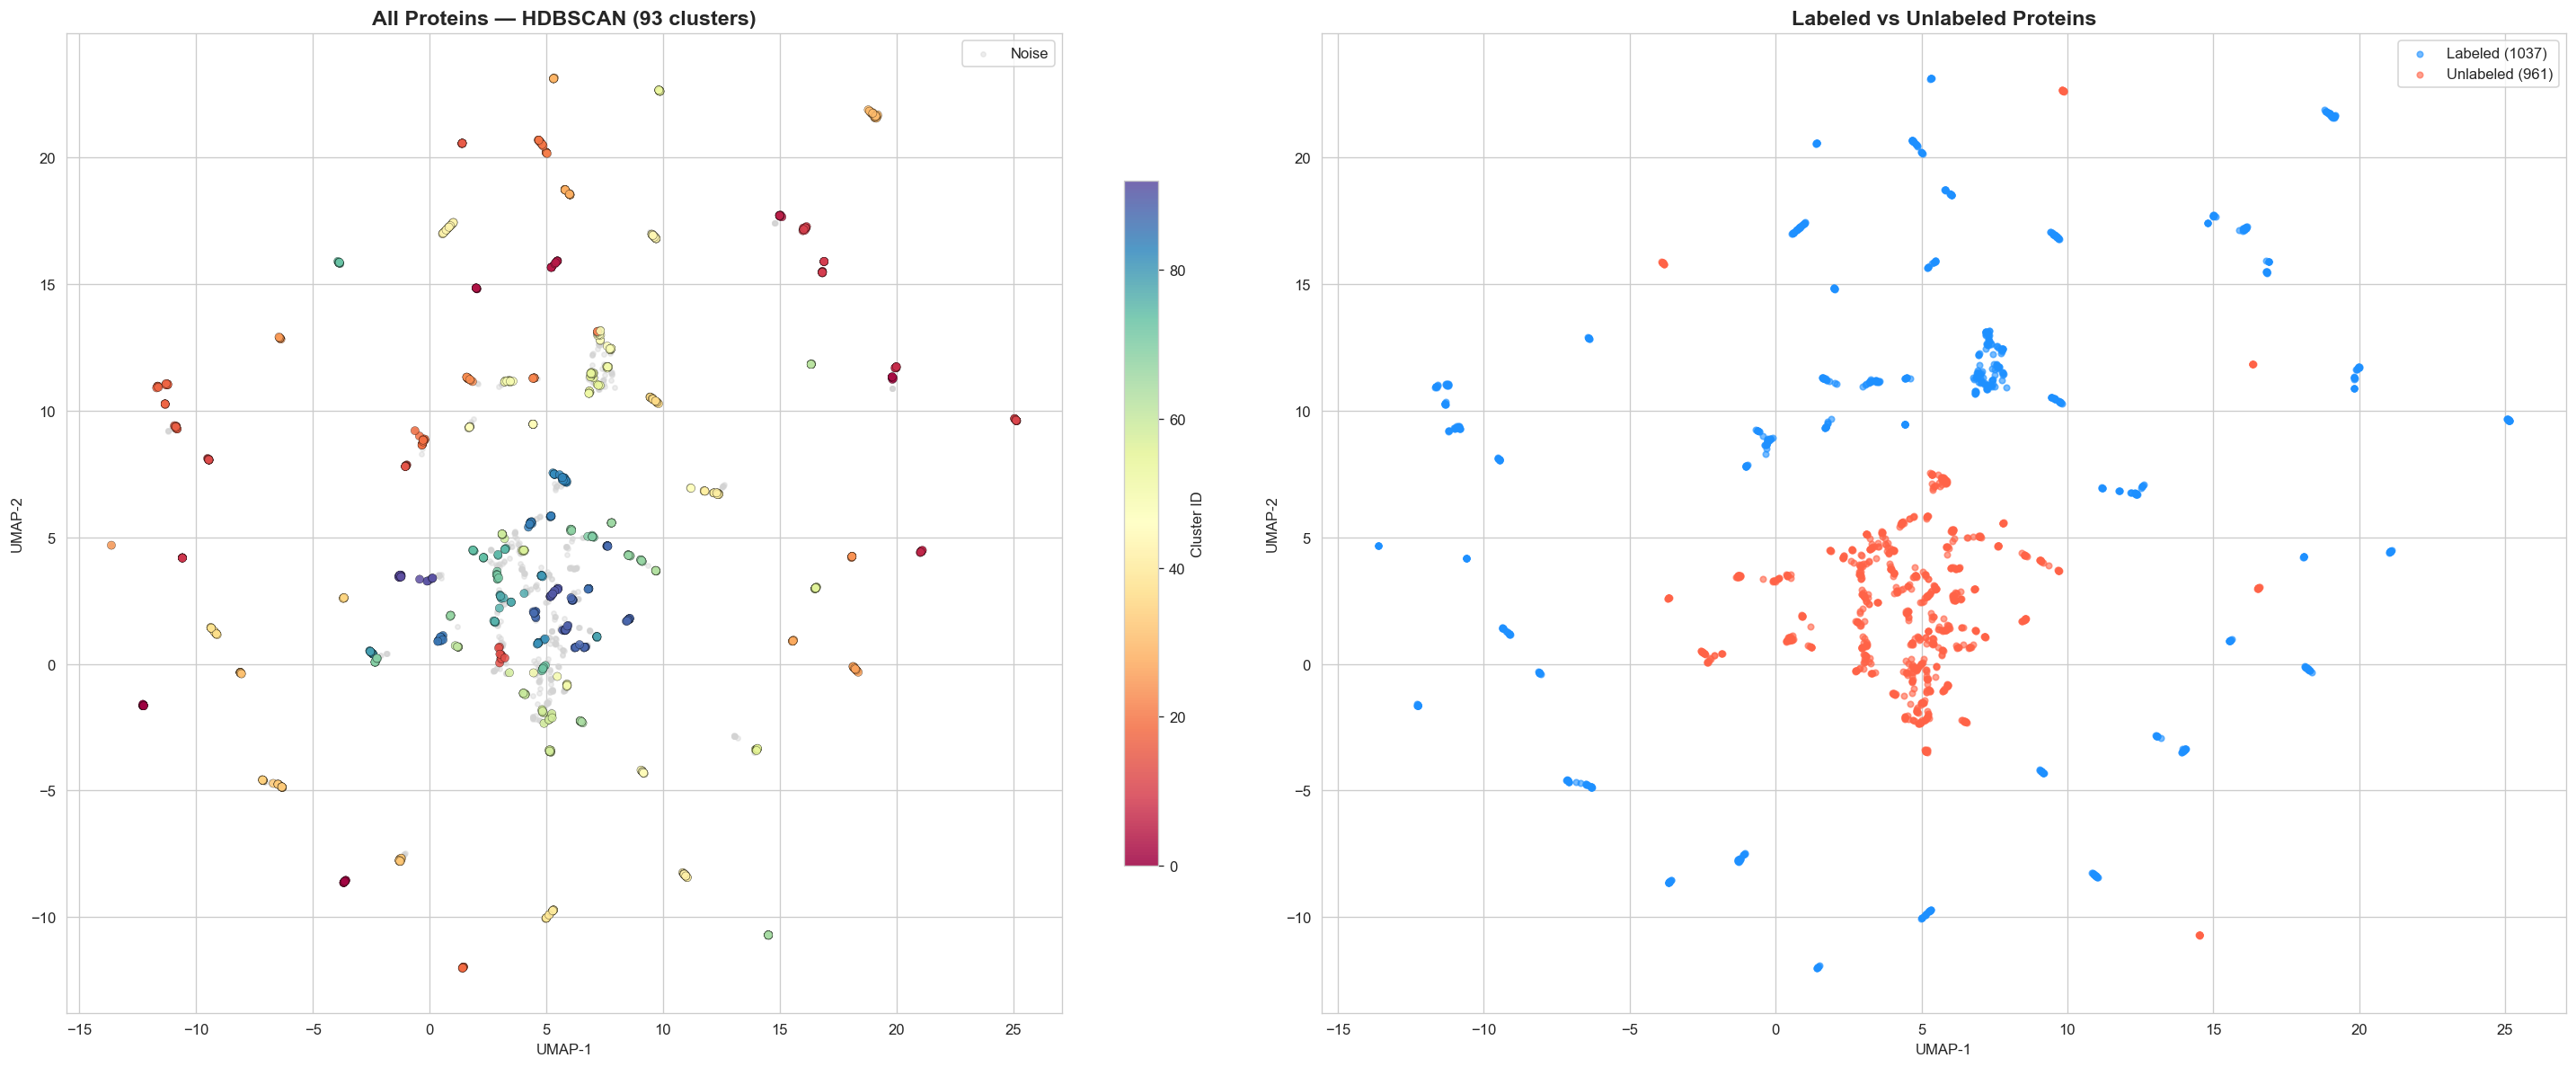

Plots saved


In [23]:
reducer = umap.UMAP(
    n_components=2,
    metric='precomputed',
    random_state=SEED,
    init='random',
)
emb_2d = reducer.fit_transform(super_matrix_dist)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

ax = axes[0]
noise_m = labels == -1
ax.scatter(emb_2d[noise_m, 0], emb_2d[noise_m, 1],
           c='lightgrey', s=10, alpha=0.4, label='Noise')
cluster_m = ~noise_m
sc = ax.scatter(emb_2d[cluster_m, 0], emb_2d[cluster_m, 1],
                c=labels[cluster_m], cmap='Spectral',
                s=30, alpha=0.85, edgecolors='black', linewidth=0.2)
ax.set_title(f'All Proteins — HDBSCAN ({n_clusters} clusters)', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
plt.colorbar(sc, ax=ax, shrink=0.7, label='Cluster ID')
ax.legend(loc='upper right')

ax = axes[1]
ax.scatter(emb_2d[is_labeled, 0], emb_2d[is_labeled, 1],
           c='dodgerblue', s=15, alpha=0.6, label=f'Labeled ({is_labeled.sum()})')
ax.scatter(emb_2d[~is_labeled, 0], emb_2d[~is_labeled, 1],
           c='tomato', s=15, alpha=0.6, label=f'Unlabeled ({(~is_labeled).sum()})')
ax.set_title('Labeled vs Unlabeled Proteins', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.legend(loc='upper right')

plt.tight_layout()
# plt.savefig(os.path.join(FIG_DIR, 'full_multimodal_clusters_v2_.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Plots saved')

#### Save Results

In [26]:
split_arr = np.array(['train'] * N_total)
split_arr[test_idx] = 'test'
source_arr = np.where(is_labeled, 'labeled', 'unlabeled')

result_df = pd.DataFrame({
    'ID':      all_ids,
    'cluster': labels,
    'source':  source_arr,
    'split':   split_arr,
})

labeled_cols = [
    'ID', 'Protein names', 'Gene Names', 'Keywords',
    'Gene Ontology (GO)', 'Function [CC]'
]
available_cols = [c for c in labeled_cols if c in text_df.columns]
if available_cols:
    result_df = result_df.merge(text_df[available_cols], on='ID', how='left')

# Build unified text column:
# - labeled rows: concatenate all available labeled metadata fields
# - unlabeled rows: use generated text from model predictions
text_cols_for_concat = [
    c for c in ['Protein names', 'Gene Names', 'Keywords', 'Gene Ontology (GO)', 'Function [CC]']
    if c in result_df.columns
]

result_df['text'] = ''
if text_cols_for_concat:
    labeled_text = (
        result_df[text_cols_for_concat]
        .fillna('')
        .astype(str)
        .apply(lambda row: ' '.join([v.strip() for v in row if v.strip()]), axis=1)
    )
    result_df.loc[result_df['source'] == 'labeled', 'text'] = labeled_text[result_df['source'] == 'labeled']

generated_text_map = pd.Series(generated_texts, index=unlabeled_ids).to_dict()
result_df.loc[result_df['source'] == 'unlabeled', 'text'] = (
    result_df.loc[result_df['source'] == 'unlabeled', 'ID']
    .map(generated_text_map)
    .fillna('')
    .astype(str)
)
result_df['text'] = result_df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

labeled_seqs_path = os.path.join(DATA_DIR, 'sequences_labeled_full.csv')
if os.path.exists(labeled_seqs_path):
    lab_seq = pd.read_csv(labeled_seqs_path)
    if 'uniref_id' in lab_seq.columns:
        lab_seq = lab_seq.rename(columns={'uniref_id': 'ID'})
    result_df = result_df.merge(lab_seq[['ID', 'subfamily']].drop_duplicates(),
                                on='ID', how='left')

result_df = result_df.sort_values(by='cluster').reset_index(drop=True)

source_breakdown = result_df.groupby(['cluster', 'source']).size().unstack(fill_value=0).head(10)
split_breakdown = result_df.groupby(['cluster', 'split']).size().unstack(fill_value=0).head(10)

# Keep source for processing/diagnostics, but remove from final saved file
result_to_save = result_df.drop(columns=['source','split', 'Protein names', 'Gene Names', 'Keywords', 'Gene Ontology (GO)', 'Function [CC]','subfamily'])

out_path = os.path.join(DATA_DIR, 'final_multimodal_clusters_v2.csv')
result_to_save.to_csv(out_path, index=False)

print(f'Saved → {out_path}')
print(f'Shape : {result_to_save.shape}')
print(f"\nNon-empty text rows: {(result_to_save['text'].str.len() > 0).sum()} / {len(result_to_save)}")
print(f'\nCluster distribution:')
print(result_to_save['cluster'].value_counts().sort_index())
print(f'\nSource breakdown:')
print(source_breakdown)
print(f'\nSplit breakdown:')
print(split_breakdown)

Saved → ../data/processed\final_multimodal_clusters_v2.csv
Shape : (1998, 3)

Non-empty text rows: 1998 / 1998

Cluster distribution:
cluster
-1     670
 0      17
 1      19
 2       7
 3      10
      ... 
 88     38
 89     13
 90     17
 91      5
 92     24
Name: count, Length: 94, dtype: int64

Source breakdown:
source   labeled  unlabeled
cluster                    
-1           236        434
 0            17          0
 1            19          0
 2             7          0
 3            10          0
 4            15          0
 5            10          0
 6            16          0
 7            13          0
 8             8          0

Split breakdown:
split    test  train
cluster             
-1        168    502
 0          5     12
 1          3     16
 2          1      6
 3          1      9
 4          4     11
 5          2      8
 6          1     15
 7          2     11
 8          1      7
